# molgan_updates
## Conditional MolGAN with Reinforcement Learning & Anti-Collapse Mechanisms

A production-ready molecular generation system trained on QM9.  
Features: WGAN-GP · RL Reward · Diversity Reward · Replay Buffer · Temperature Noise · Checkpointing


In [1]:
# Install PyTorch Geometric dependencies (Colab-compatible)

import torch
import sys

print("Torch version:", torch.__version__)
print("Python version:", sys.version)

# Install required packages
!pip install rdkit
!pip install  torch-geometric

Torch version: 2.10.0+cu128
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.6 MB/s eta 0:00:00


## Section 1 — Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
import os
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader

from torch_geometric.datasets import QM9
from torch_geometric.data import Data

from rdkit import Chem
from rdkit.Chem import QED, Descriptors, rdMolDescriptors, Draw, AllChem

try:
    import py3Dmol
    PY3DMOL_AVAILABLE = True
except ImportError:
    PY3DMOL_AVAILABLE = False
    print("py3Dmol not installed — 3D visualisation will be skipped.")

from IPython.display import display, Image
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


py3Dmol not installed — 3D visualisation will be skipped.
Using device: cuda


## Section 2 — Global Configuration

In [3]:
# ── Molecule constraints ──────────────────────────────────────────────────────
MAX_ATOMS   = 9                        # heavy atoms only (GetNumHeavyAtoms)
ATOM_TYPES  = ['C', 'N', 'O', 'F']
NUM_ATOM_FEATURES = len(ATOM_TYPES)

# ── Model dimensions ─────────────────────────────────────────────────────────
Z_DIM      = 32    # latent noise dimension
HIDDEN_DIM = 128

COND_DIM   = 2     # [qed_norm, logp_norm]

# ── Training hyper-parameters ─────────────────────────────────────────────────
DEFAULT_TEMPERATURE = 0.8
LAMBDA_GP           = 10     # gradient penalty weight
LAMBDA_RL           = 0.5    # RL reward weight
LAMBDA_DIVERSITY    = 0.2    # diversity reward weight
BUFFER_SIZE         = 5000   # replay-buffer capacity
NUM_EPOCHS          = 50
BATCH_SIZE          = 32
LR_G                = 1e-4
LR_D                = 1e-4
N_CRITIC            = 5      # discriminator steps per generator step

# ── I/O ───────────────────────────────────────────────────────────────────────
SAVE_INTERVAL  = 5
CHECKPOINT_DIR = "checkpoints"
DATA_ROOT      = "./data"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

print("Configuration loaded.")
print(f"  MAX_ATOMS  : {MAX_ATOMS} (heavy atoms via GetNumHeavyAtoms)")
print(f"  ATOM_TYPES : {ATOM_TYPES}")
print(f"  Z_DIM      : {Z_DIM}")
print(f"  EPOCHS     : {NUM_EPOCHS}")


Configuration loaded.
  MAX_ATOMS  : 9 (heavy atoms via GetNumHeavyAtoms)
  ATOM_TYPES : ['C', 'N', 'O', 'F']
  Z_DIM      : 32
  EPOCHS     : 50


## Section 3 — Load & Filter QM9 Dataset

> **Important:** filtering uses `mol.GetNumHeavyAtoms()` — hydrogens are excluded.


In [4]:
import os
import glob
import torch
from torch_geometric.datasets import QM9
from torch_geometric.data import Data
from rdkit import Chem


class SafeQM9(QM9):
    """
    Safe wrapper around PyG QM9 dataset.

    Prevents crashes caused by:
        mol = None
        GetNumAtoms() failure
        GetConformer() failure

    Invalid molecules are skipped automatically.
    """

    def process(self):

        from rdkit.Chem import SDMolSupplier

        # Locate SDF file downloaded by QM9
        sdf_files = glob.glob(
            os.path.join(self.raw_dir, "*.sdf")
        )

        # If dataset not downloaded yet,
        # fall back to default processing
        if not sdf_files:

            print(
                "[SafeQM9] No SDF found — "
                "using default processing."
            )

            super().process()
            return

        sdf_path = sdf_files[0]

        supplier = SDMolSupplier(
            sdf_path,
            removeHs=False,
            sanitize=False
        )

        data_list = []
        skipped = 0

        for mol in supplier:

            # Guard 1 — None molecule
            if mol is None:
                skipped += 1
                continue

            # Guard 2 — Atom count
            try:
                n_atoms = mol.GetNumAtoms()
            except Exception:
                skipped += 1
                continue

            if n_atoms == 0:
                skipped += 1
                continue

            # Guard 3 — Conformer
            try:
                conf = mol.GetConformer()

                pos = torch.tensor(
                    [
                        [
                            conf.GetAtomPosition(i).x,
                            conf.GetAtomPosition(i).y,
                            conf.GetAtomPosition(i).z
                        ]
                        for i in range(n_atoms)
                    ],
                    dtype=torch.float
                )

            except Exception:
                skipped += 1
                continue

            # Atomic numbers
            try:
                z = torch.tensor(
                    [
                        atom.GetAtomicNum()
                        for atom in mol.GetAtoms()
                    ],
                    dtype=torch.long
                )
            except Exception:
                skipped += 1
                continue

            # SMILES extraction
            try:
                Chem.SanitizeMol(mol)
                smiles = Chem.MolToSmiles(mol)
            except Exception:
                smiles = ""

            # Build edge list
            rows = []
            cols = []

            for bond in mol.GetBonds():

                i = bond.GetBeginAtomIdx()
                j = bond.GetEndAtomIdx()

                rows += [i, j]
                cols += [j, i]

            if rows:

                edge_index = torch.tensor(
                    [rows, cols],
                    dtype=torch.long
                )

            else:

                edge_index = torch.zeros(
                    (2, 0),
                    dtype=torch.long
                )

            data = Data(
                z=z,
                pos=pos,
                edge_index=edge_index,
                smiles=smiles
            )

            data_list.append(data)

        print(
            f"[SafeQM9] Skipped {skipped} invalid molecules."
        )

        print(
            f"[SafeQM9] Loaded {len(data_list)} valid molecules."
        )

        data, slices = self.collate(data_list)

        torch.save(
            (data, slices),
            self.processed_paths[0]
        )


print("SafeQM9 class ready.")

SafeQM9 class ready.


In [8]:
print("SafeQM9 defined?", "SafeQM9" in globals())

SafeQM9 defined? True


In [9]:
import pandas as pd
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit import RDLogger

# OPTIONAL: silence RDKit warnings (cosmetic)
RDLogger.DisableLog('rdApp.*')

print("Loading QM9 dataset via SafeQM9 …")

raw_dataset = SafeQM9(root=DATA_ROOT)

print(f"Total QM9 entries: {len(raw_dataset)}")

filtered_data = []

skipped_no_smiles = 0
skipped_invalid_mol = 0
skipped_atom_limit = 0
skipped_property_error = 0

for data in tqdm(raw_dataset, desc="Filtering molecules"):

    # ---- Safe SMILES access ----
    smiles = getattr(data, "smiles", None)

    if smiles is None or smiles == "":
        skipped_no_smiles += 1
        continue

    # ---- Create molecule ----
    mol = Chem.MolFromSmiles(smiles, sanitize=False)

    if mol is None:
        skipped_invalid_mol += 1
        continue

    # ---- Explicit sanitization ----
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        skipped_invalid_mol += 1
        continue

    # ---- Heavy atom filter ----
    if mol.GetNumHeavyAtoms() > MAX_ATOMS:
        skipped_atom_limit += 1
        continue

    # ---- Property computation ----
    try:
        qed_val = QED.qed(mol)
        logp_val = Descriptors.MolLogP(mol)
    except Exception:
        skipped_property_error += 1
        continue

    # ---- Store result ----
    filtered_data.append({
        "smiles": smiles,
        "qed": float(qed_val),
        "logp": float(logp_val),
    })

# ---- Create DataFrame ----
df = pd.DataFrame(filtered_data)

# ---- Summary ----
print("\nFiltering summary")
print("------------------------------")
print("Total molecules:", len(raw_dataset))
print("Filtered molecules:", len(df))
print("Skipped no smiles:", skipped_no_smiles)
print("Skipped invalid mol:", skipped_invalid_mol)
print("Skipped atom limit:", skipped_atom_limit)
print("Skipped property error:", skipped_property_error)

# ---- Statistics ----
print("\nStatistics")
print(df[["qed", "logp"]].describe())

Loading QM9 dataset via SafeQM9 …


Processing...


[SafeQM9] Skipped 0 invalid molecules.
[SafeQM9] Loaded 133885 valid molecules.


Done!


Total QM9 entries: 133885


Filtering molecules: 100%|██████████| 133885/133885 [03:47<00:00, 587.52it/s]



Filtering summary
------------------------------
Total molecules: 133885
Filtered molecules: 131970
Skipped no smiles: 1915
Skipped invalid mol: 0
Skipped atom limit: 0
Skipped property error: 0

Statistics
                 qed           logp
count  131970.000000  131970.000000
mean        0.461367       0.139063
std         0.077932       1.165557
min         0.094257      -5.003900
25%         0.416107      -0.637250
50%         0.470717       0.186000
75%         0.515782       0.942500
max         0.668797       3.756900


## Section 4 — Normalization Functions

In [11]:
def normalize_inputs(qed: float, logp: float):
    """Normalize QED to [0,1] and logP to [0,1] via (logp+5)/10."""
    qed  = max(0.0, min(1.0, qed))
    logp = (logp + 5) / 10.0
    logp = max(0.0, min(1.0, logp))
    return qed, logp

def denormalize_logp(logp_norm: float) -> float:
    """Inverse of the logP normalization."""
    return logp_norm * 10.0 - 5.0


# Quick sanity check
_q, _l = normalize_inputs(0.85, 2.3)
print(f"normalize_inputs(0.85, 2.3) → qed={_q:.4f}, logp_norm={_l:.4f}")
print(f"denormalize_logp({_l:.4f})  → {denormalize_logp(_l):.4f}  (expected 2.3)")


normalize_inputs(0.85, 2.3) → qed=0.8500, logp_norm=0.7300
denormalize_logp(0.7300)  → 2.3000  (expected 2.3)


## Section 5 — RDKit Graph Conversion

In [12]:
'''ATOM_TO_IDX = {atom: idx for idx, atom in enumerate(ATOM_TYPES)}

def smiles_to_graph(smiles: str):
    """
    Convert a SMILES string to padded adjacency + node-feature matrices.

    Returns
    -------
    adj   : np.ndarray  shape (MAX_ATOMS, MAX_ATOMS)  — binary adjacency
    nodes : np.ndarray  shape (MAX_ATOMS, NUM_ATOM_FEATURES) — one-hot atoms
    None, None if conversion fails.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    n = mol.GetNumHeavyAtoms()
    if n > MAX_ATOMS:
        return None, None

    # ── Node features (one-hot encoded atom type) ──────────────────────────
    nodes = np.zeros((MAX_ATOMS, NUM_ATOM_FEATURES), dtype=np.float32)
    for i, atom in enumerate(mol.GetAtoms()):
        symbol = atom.GetSymbol()
        if symbol in ATOM_TO_IDX:
            nodes[i, ATOM_TO_IDX[symbol]] = 1.0

    # ── Adjacency matrix (symmetric, binary) ──────────────────────────────
    adj = np.zeros((MAX_ATOMS, MAX_ATOMS), dtype=np.float32)
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        if i < MAX_ATOMS and j < MAX_ATOMS:
            adj[i, j] = 1.0
            adj[j, i] = 1.0

    return adj, nodes


# Verify on a simple molecule
_adj, _nodes = smiles_to_graph("CCO")
print(f"Ethanol — adj shape: {_adj.shape}, nodes shape: {_nodes.shape}")
print("Node features (first 3 rows):\n", _nodes[:3])'''


'ATOM_TO_IDX = {atom: idx for idx, atom in enumerate(ATOM_TYPES)}\n\ndef smiles_to_graph(smiles: str):\n    """\n    Convert a SMILES string to padded adjacency + node-feature matrices.\n\n    Returns\n    -------\n    adj   : np.ndarray  shape (MAX_ATOMS, MAX_ATOMS)  — binary adjacency\n    nodes : np.ndarray  shape (MAX_ATOMS, NUM_ATOM_FEATURES) — one-hot atoms\n    None, None if conversion fails.\n    """\n    mol = Chem.MolFromSmiles(smiles)\n    if mol is None:\n        return None, None\n\n    n = mol.GetNumHeavyAtoms()\n    if n > MAX_ATOMS:\n        return None, None\n\n    # ── Node features (one-hot encoded atom type) ──────────────────────────\n    nodes = np.zeros((MAX_ATOMS, NUM_ATOM_FEATURES), dtype=np.float32)\n    for i, atom in enumerate(mol.GetAtoms()):\n        symbol = atom.GetSymbol()\n        if symbol in ATOM_TO_IDX:\n            nodes[i, ATOM_TO_IDX[symbol]] = 1.0\n\n    # ── Adjacency matrix (symmetric, binary) ──────────────────────────────\n    adj = np.zeros

In [13]:
ATOM_TO_IDX = {atom: idx for idx, atom in enumerate(ATOM_TYPES)}
def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None, None

    # -------- STRICT SIZE CHECK --------

    if mol.GetNumHeavyAtoms() > MAX_ATOMS:
        return None, None

    num_atoms = mol.GetNumAtoms()

    if num_atoms > MAX_ATOMS:
        return None, None

    # -------- NODE MATRIX --------

    nodes = np.zeros(
        (MAX_ATOMS, len(ATOM_TO_IDX)),
        dtype=np.float32
    )

    for i, atom in enumerate(mol.GetAtoms()):

        # CRITICAL SAFETY
        if i >= MAX_ATOMS:
            break

        symbol = atom.GetSymbol()

        if symbol in ATOM_TO_IDX:
            nodes[i, ATOM_TO_IDX[symbol]] = 1.0

    # -------- ADJACENCY MATRIX --------

    adj = np.zeros(
        (MAX_ATOMS, MAX_ATOMS),
        dtype=np.float32
    )

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # CRITICAL SAFETY
        if i >= MAX_ATOMS or j >= MAX_ATOMS:
            continue

        adj[i, j] = 1.0
        adj[j, i] = 1.0

    return adj, nodes

## Section 6 — MolDataset Class

In [14]:
class MolDataset(Dataset):
    """
    PyTorch Dataset wrapping the filtered QM9 DataFrame.

    Each item returns:
        adj   (MAX_ATOMS, MAX_ATOMS)         — adjacency matrix tensor
        nodes (MAX_ATOMS, NUM_ATOM_FEATURES) — node features tensor
        cond  (COND_DIM,)                    — normalised [qed, logp]
    """

    def __init__(self, dataframe: pd.DataFrame):
        records = []
        for _, row in dataframe.iterrows():
            adj, nodes = smiles_to_graph(row['smiles'])
            if adj is None:
                continue
            qed_n, logp_n = normalize_inputs(row['qed'], row['logp'])
            records.append({
                'adj'   : adj,
                'nodes' : nodes,
                'cond'  : np.array([qed_n, logp_n], dtype=np.float32),
                'smiles': row['smiles'],
            })
        self.records = records
        print(f"MolDataset created with {len(self.records)} valid molecules.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        return (
            torch.tensor(r['adj'],   dtype=torch.float32),
            torch.tensor(r['nodes'], dtype=torch.float32),
            torch.tensor(r['cond'],  dtype=torch.float32),
        )


mol_dataset = MolDataset(df)


MolDataset created with 130675 valid molecules.


## Section 7 — DataLoader

In [15]:
train_loader = DataLoader(
    mol_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    drop_last  = True,   # keeps batch sizes uniform for matrix ops
    num_workers= 0,
)

print(f"DataLoader ready — {len(train_loader)} batches per epoch.")


DataLoader ready — 4083 batches per epoch.


## Section 8 — Generator Model

In [85]:
class Generator(nn.Module):
    """
    Conditional generator.

    Input  : z (B, Z_DIM)  + cond (B, COND_DIM)
    Output : nodes (B, MAX_ATOMS, NUM_ATOM_FEATURES)
             adj   (B, MAX_ATOMS, MAX_ATOMS)
    """

    def __init__(self):
        super().__init__()
        in_dim  = Z_DIM + COND_DIM
        out_nodes = MAX_ATOMS * NUM_ATOM_FEATURES
        out_adj   = MAX_ATOMS * MAX_ATOMS

        self.shared = nn.Sequential(
            nn.Linear(in_dim, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.node_head = nn.Linear(HIDDEN_DIM, out_nodes)
        self.adj_head  = nn.Linear(HIDDEN_DIM, out_adj)

    def forward(self, z, cond):
        x     = torch.cat([z, cond], dim=-1)          # (B, Z+C)
        h     = self.shared(x)                         # (B, H)
        nodes = self.node_head(h).view(-1, MAX_ATOMS, NUM_ATOM_FEATURES)
        nodes = torch.softmax(nodes, dim=-1)           # one-hot-like probs
        adj   = self.adj_head(h).view(-1, MAX_ATOMS, MAX_ATOMS)
        adj   = torch.sigmoid(adj)                     # ∈ (0,1) edge probs
        # Symmetrise to ensure undirected graph
        adj   = (adj + adj.transpose(1, 2)) / 2.0
        return nodes, adj


generator = Generator().to(device)
print(generator)
print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")


Generator(
  (shared): Sequential(
    (0): Linear(in_features=34, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (node_head): Linear(in_features=128, out_features=36, bias=True)
  (adj_head): Linear(in_features=128, out_features=81, bias=True)
)
Generator parameters: 36,085


## Section 9 — Discriminator Model (WGAN-GP)

In [86]:
class Discriminator(nn.Module):
    """
    Conditional WGAN discriminator (critic).

    No sigmoid output — raw score for Wasserstein distance.

    Input  : nodes (B, MAX_ATOMS, NUM_ATOM_FEATURES)
             adj   (B, MAX_ATOMS, MAX_ATOMS)
             cond  (B, COND_DIM)
    Output : score (B, 1)
    """

    def __init__(self):
        super().__init__()
        flat_nodes = MAX_ATOMS * NUM_ATOM_FEATURES
        flat_adj   = MAX_ATOMS * MAX_ATOMS
        in_dim     = flat_nodes + flat_adj + COND_DIM

        self.net = nn.Sequential(
            nn.Linear(in_dim, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, 1),
            # ── NO sigmoid — WGAN-GP requires raw scores ──
        )

    def forward(self, nodes, adj, cond):
        flat = torch.cat([
            nodes.view(nodes.size(0), -1),
            adj.view(adj.size(0),   -1),
            cond,
        ], dim=-1)
        return self.net(flat)


discriminator = Discriminator().to(device)
print(discriminator)
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")


Discriminator(
  (net): Sequential(
    (0): Linear(in_features=119, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)
Discriminator parameters: 32,001


In [87]:
opt_g = optim.Adam(generator.parameters(),     lr=LR_G, betas=(0.5, 0.9))
opt_d = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.9))

## Section 10 — Gradient Penalty (WGAN-GP)

In [18]:
def compute_gradient_penalty(discriminator, real_nodes, real_adj,
                             fake_nodes, fake_adj, cond):
    """
    WGAN-GP gradient penalty.

    Interpolates between real and fake samples and penalises
    the gradient norm deviation from 1.
    """
    B = real_nodes.size(0)
    alpha = torch.rand(B, 1, 1, device=device)   # broadcast over (MAX_ATOMS, feat)

    # Interpolated nodes
    interp_nodes = (alpha * real_nodes +
                    (1 - alpha) * fake_nodes).requires_grad_(True)

    alpha_adj = alpha.view(B, 1, 1)
    interp_adj = (alpha_adj * real_adj +
                  (1 - alpha_adj) * fake_adj).requires_grad_(True)

    d_interp = discriminator(interp_nodes, interp_adj, cond)

    gradients = torch.autograd.grad(
        outputs    = d_interp,
        inputs     = [interp_nodes, interp_adj],
        grad_outputs = torch.ones_like(d_interp),
        create_graph = True,
        retain_graph = True,
    )

    grad_nodes = gradients[0].view(B, -1)
    grad_adj   = gradients[1].view(B, -1)
    grad_norm  = torch.cat([grad_nodes, grad_adj], dim=-1).norm(2, dim=1)
    penalty    = ((grad_norm - 1) ** 2).mean()
    return penalty


print("compute_gradient_penalty defined.")


compute_gradient_penalty defined.


## Section 11 — Replay Buffer

In [19]:
replay_buffer = []   # list of SMILES strings


def add_to_buffer(smiles_list: list):
    """Add valid, unique SMILES to the replay buffer (capped at BUFFER_SIZE)."""
    global replay_buffer
    for smi in smiles_list:
        if smi and smi not in replay_buffer:
            replay_buffer.append(smi)
    if len(replay_buffer) > BUFFER_SIZE:
        replay_buffer = replay_buffer[-BUFFER_SIZE:]


def sample_from_buffer(n: int = 32) -> list:
    """Random sample of up to n SMILES from the buffer."""
    if len(replay_buffer) == 0:
        return []
    k = min(n, len(replay_buffer))
    return random.sample(replay_buffer, k)


print("Replay buffer utilities ready.")


Replay buffer utilities ready.


## Section 12 — Diversity Reward

In [20]:
def diversity_reward(smiles_list: list) -> float:
    """
    Ratio of unique SMILES to total SMILES in the batch.

    Returns a value in [0, 1].  Higher = more diverse batch.
    """
    if not smiles_list:
        return 0.0
    unique = len(set(smiles_list))
    total  = len(smiles_list)
    return unique / total


# Quick test
_test = ["CCO", "CCN", "CCO", "CCC", "CCN"]
print(f"diversity_reward test: {diversity_reward(_test):.3f}  (expected ~0.600)")


diversity_reward test: 0.600  (expected ~0.600)


## Section 13 — Property Calculation

In [89]:
try:
    from rdkit.Chem import RDConfig
    import sys
    sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
    import sascorer
    SA_AVAILABLE = True
except Exception:
    SA_AVAILABLE = False
    print("SA Score module not available — will return 0.0 as placeholder.")


def calculate_qed(mol) -> float:
    """Drug-likeness score ∈ [0, 1]."""
    try:
        return float(QED.qed(mol))
    except Exception:
        return 0.0


def calculate_logp(mol) -> float:
    """Wildman-Crippen LogP."""
    try:
        return float(Descriptors.MolLogP(mol))
    except Exception:
        return 0.0


def calculate_sa_score(mol) -> float:
    """Synthetic accessibility score ∈ [1, 10] (lower = easier to synthesise)."""
    if not SA_AVAILABLE:
        return 0.0
    try:
        return float(sascorer.calculateScore(mol))
    except Exception:
        return 0.0


def calculate_molecular_weight(mol) -> float:
    """Exact molecular weight in Da."""
    try:
        return float(Descriptors.ExactMolWt(mol))
    except Exception:
        return 0.0


# Sanity check




## Section 14 — Reinforcement Learning Reward

> **Note:** Temperature is used only for noise generation, **not** in the reward function.


In [90]:
def compute_rl_reward(smiles_list: list,
                      target_qed : float,
                      target_logp: float) -> float:
    """
    Composite RL reward combining property matching and diversity.

    property_reward = (1 - |pred_qed  - target_qed|)
                    + (1 - |pred_logp - target_logp|)
    final_reward    = property_reward + LAMBDA_DIVERSITY * diversity_reward

    Temperature is NOT used here.
    """
    if not smiles_list:
        return 0.0

    property_rewards = []
    valid_smiles     = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        valid_smiles.append(smi)
        pred_qed  = calculate_qed(mol)
        pred_logp = calculate_logp(mol)

        pr = (1.0 - abs(pred_qed  - target_qed)) +              (1.0 - abs(pred_logp - target_logp))
        property_rewards.append(pr)

    if not property_rewards:
        return 0.0

    mean_prop_reward = np.mean(property_rewards)
    div_reward       = diversity_reward(valid_smiles)
    return mean_prop_reward + LAMBDA_DIVERSITY * div_reward


print("compute_rl_reward defined (temperature excluded from reward).")


compute_rl_reward defined (temperature excluded from reward).


## Section 15 — Checkpoint System

In [23]:
def save_checkpoint(epoch: int,
                    generator, discriminator,
                    opt_g, opt_d,
                    losses: dict):
    """Save model + optimiser states; keeps the last two checkpoints."""
    path = os.path.join(CHECKPOINT_DIR, f"ckpt_epoch_{epoch:04d}.pt")
    torch.save({
        'epoch'       : epoch,
        'generator'   : generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'opt_g'       : opt_g.state_dict(),
        'opt_d'       : opt_d.state_dict(),
        'losses'      : losses,
    }, path)
    print(f"  [CKPT] Saved → {path}")

    # Keep only the two most recent checkpoints to save disk space
    all_ckpts = sorted([
        f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("ckpt_epoch_")
    ])
    for old in all_ckpts[:-2]:
        os.remove(os.path.join(CHECKPOINT_DIR, old))


def load_latest_checkpoint(generator, discriminator, opt_g, opt_d):
    """Resume from the most recent checkpoint if one exists."""
    all_ckpts = sorted([
        f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("ckpt_epoch_")
    ])
    if not all_ckpts:
        print("No checkpoint found — starting from scratch.")
        return 0, {}

    path  = os.path.join(CHECKPOINT_DIR, all_ckpts[-1])
    ckpt  = torch.load(path, map_location=device)
    generator.load_state_dict(ckpt['generator'])
    discriminator.load_state_dict(ckpt['discriminator'])
    opt_g.load_state_dict(ckpt['opt_g'])
    opt_d.load_state_dict(ckpt['opt_d'])
    print(f"  [CKPT] Resumed from epoch {ckpt['epoch']} ({path})")
    return ckpt['epoch'], ckpt.get('losses', {})


print("Checkpoint utilities ready.")


Checkpoint utilities ready.


## Section 16 — User Input Interface

In [84]:
# ── Generation parameters (edit these before running) ─────────────────────────
NUMBER_OF_MOLECULES = int(input("Number of molecules"))       # how many molecules to generate
TARGET_QED          = float(input("QED (0-1)"))    # desired QED  ∈ [0, 1]
TARGET_LOGP         = float(input("Lipophilicity(<0-Very hydrophilic,0-3 -balanced,3-5 -lipophilic)"))  # desired logP
TEMPERATURE         = None    # set to float to override, or None for default

# ── Apply defaults ────────────────────────────────────────────────────────────
if TEMPERATURE is None:
    TEMPERATURE = DEFAULT_TEMPERATURE

print(f"Generation settings:")
print(f"  Molecules to generate : {NUMBER_OF_MOLECULES}")
print(f"  Target QED            : {TARGET_QED}")
print(f"  Target logP           : {TARGET_LOGP}")
print(f"  Noise temperature     : {TEMPERATURE}")


Number of molecules50
QED (0-1)0.5
Lipophilicity(<0-Very hydrophilic,0-3 -balanced,3-5 -lipophilic)2.8
Generation settings:
  Molecules to generate : 50
  Target QED            : 0.5
  Target logP           : 2.8
  Noise temperature     : 0.8


## Section 17 — Training Loop

In [27]:
# ── Optimisers ────────────────────────────────────────────────────────────────
opt_g = optim.Adam(generator.parameters(),     lr=LR_G, betas=(0.5, 0.9))
opt_d = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.9))

# ── Resume if checkpoint exists ───────────────────────────────────────────────
start_epoch, history = load_latest_checkpoint(
    generator, discriminator, opt_g, opt_d
)

loss_history = history if history else {'d_loss': [], 'g_loss': [], 'rl_reward': []}

def graph_to_smiles(nodes_batch, adj_batch) -> list:
    """
    Greedy decode a generator output batch into SMILES strings.
    Returns a list of SMILES (empty string if decoding fails).
    """
    smiles_out = []
    nodes_np = nodes_batch.detach().cpu().numpy()
    adj_np   = adj_batch.detach().cpu().numpy()

    for b in range(nodes_np.shape[0]):
        try:
            atom_indices = np.argmax(nodes_np[b], axis=-1)   # (MAX_ATOMS,)
            adj_mat      = (adj_np[b] > 0.5).astype(int)

            rw_mol = Chem.RWMol()
            atom_map = {}
            for i in range(MAX_ATOMS):
                sym = ATOM_TYPES[atom_indices[i]]
                idx = rw_mol.AddAtom(Chem.Atom(sym))
                atom_map[i] = idx

            for i in range(MAX_ATOMS):
                for j in range(i + 1, MAX_ATOMS):
                    if adj_mat[i, j] == 1:
                        rw_mol.AddBond(atom_map[i], atom_map[j],
                                       Chem.BondType.SINGLE)

            Chem.SanitizeMol(rw_mol)
            smiles_out.append(Chem.MolToSmiles(rw_mol))
        except Exception:
            smiles_out.append("")

    return smiles_out


# ── Training ──────────────────────────────────────────────────────────────────
print(f"Starting training from epoch {start_epoch + 1} → {NUM_EPOCHS}")

for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
    generator.train()
    discriminator.train()

    epoch_d_losses  = []
    epoch_g_losses  = []
    epoch_rl_rewards = []

    for batch_idx, (real_adj, real_nodes, cond) in enumerate(train_loader):
        real_adj   = real_adj.to(device)
        real_nodes = real_nodes.to(device)
        cond       = cond.to(device)
        B          = real_adj.size(0)

        # ── Step 1: Train Discriminator (N_CRITIC times) ─────────────────
        for _ in range(N_CRITIC):
            opt_d.zero_grad()

            # Temperature-scaled noise for exploration
            z = torch.randn(B, Z_DIM, device=device) * TEMPERATURE
            fake_nodes, fake_adj = generator(z, cond)

            d_real = discriminator(real_nodes, real_adj, cond)
            d_fake = discriminator(fake_nodes.detach(), fake_adj.detach(), cond)

            gp     = compute_gradient_penalty(
                discriminator,
                real_nodes, real_adj,
                fake_nodes.detach(), fake_adj.detach(),
                cond,
            )
            d_loss = -d_real.mean() + d_fake.mean() + LAMBDA_GP * gp
            d_loss.backward()
            opt_d.step()

        # ── Step 2: Train Generator ───────────────────────────────────────
        opt_g.zero_grad()

        z = torch.randn(B, Z_DIM, device=device) * TEMPERATURE
        fake_nodes, fake_adj = generator(z, cond)

        d_fake_g   = discriminator(fake_nodes, fake_adj, cond)
        adv_loss   = -d_fake_g.mean()

        # Decode to SMILES for RL reward
        batch_smiles = graph_to_smiles(fake_nodes, fake_adj)
        add_to_buffer(batch_smiles)

        rl_reward = compute_rl_reward(
            batch_smiles, TARGET_QED, TARGET_LOGP
        )
        rl_loss   = -torch.tensor(rl_reward, dtype=torch.float32, device=device)

        g_loss = adv_loss + LAMBDA_RL * rl_loss
        g_loss.backward()
        opt_g.step()

        epoch_d_losses.append(d_loss.item())
        epoch_g_losses.append(g_loss.item())
        epoch_rl_rewards.append(rl_reward)

    mean_d   = np.mean(epoch_d_losses)
    mean_g   = np.mean(epoch_g_losses)
    mean_rl  = np.mean(epoch_rl_rewards)

    loss_history['d_loss'].append(mean_d)
    loss_history['g_loss'].append(mean_g)
    loss_history['rl_reward'].append(mean_rl)

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}] "
          f"D={mean_d:+.4f}  G={mean_g:+.4f}  RL={mean_rl:.4f}  "
          f"Buffer={len(replay_buffer)}")

    # ── Checkpoint ────────────────────────────────────────────────────────
    if epoch % SAVE_INTERVAL == 0:
        save_checkpoint(epoch, generator, discriminator,
                        opt_g, opt_d, loss_history)

print("\nTraining complete.")

No checkpoint found — starting from scratch.
Starting training from epoch 1 → 50


KeyboardInterrupt: 

###Section 18 — LOADING CHECKPOINT

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
import os

os.listdir("/content/drive/MyDrive")

['24BD1A665Z_V.Nandhi vardhan reddy.ipynb',
 'WhatsApp Image 2025-11-23 at 12.26.04 PM.jpeg',
 'OS Groups.gsheet',
 'OS Groups (1).pdf',
 'OS Groups.pdf',
 'FinalList-PS.xlsx',
 'Payment ',
 'Screenshot_2026-03-02-17-18-10-08_6012fa4d4ddec268fc5c7112cbb265e7.jpg',
 'Assignment 1_ Introduction to Data Science, AI-ML & Python Basics.pdf',
 'Colab Notebooks',
 'molgan_training_(1).ipynb',
 'MOLGAN_PROJECT.ipynb',
 'nandu_model.zip',
 'molgan_updates.ipynb']

In [95]:
import zipfile

zip_path = "/content/drive/MyDrive/nandu_model.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Unzipped successfully")

Unzipped successfully


In [96]:
import torch

checkpoint_path = "/content/nandu_model/ckpt_epoch_0050.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cuda",   # or "cpu"
    weights_only=False     # ⭐ FIX
)

generator.load_state_dict(checkpoint["generator"])
discriminator.load_state_dict(checkpoint["discriminator"])

print("Loaded epoch:", checkpoint["epoch"])

generator.eval()
discriminator.eval()

Loaded epoch: 50


Discriminator(
  (net): Sequential(
    (0): Linear(in_features=119, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

##section-19 MOLECULE GENERATION

In [109]:
def generate_molecules(number_of_molecules: int,
                       target_qed : float,
                       target_logp: float,
                       temperature: float = DEFAULT_TEMPERATURE):
    """
    Generate `number_of_molecules` molecules conditioned on
    (target_qed, target_logp) with temperature-scaled noise.

    Returns
    -------
    valid_mols   : list of RDKit Mol objects
    valid_smiles : list of SMILES strings
    """
    generator.eval()

    qed_n, logp_n = normalize_inputs(target_qed, target_logp)
    cond_vec = torch.tensor(
        [[qed_n, logp_n]], dtype=torch.float32, device=device
    ).repeat(number_of_molecules, 1)   # (N, COND_DIM)

    with torch.no_grad():
        z         = torch.randn(number_of_molecules, Z_DIM, device=device) * temperature
        gen_nodes, gen_adj = generator(z, cond_vec)

    raw_smiles   = graph_to_smiles(gen_nodes, gen_adj)
    valid_mols   = []
    valid_smiles = []

    for smi in raw_smiles:
        if smi:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                valid_mols.append(mol)
                valid_smiles.append(smi)

    print(f"Generated {number_of_molecules} molecules → "
          f"{len(valid_mols)} valid ({100*len(valid_mols)/number_of_molecules:.1f}%)")
    return valid_mols, valid_smiles


# ── Run generation ────────────────────────────────────────────────────────────
generated_mols, generated_smiles = generate_molecules(
    number_of_molecules = NUMBER_OF_MOLECULES,
    target_qed          = TARGET_QED,
    target_logp         = TARGET_LOGP,
    temperature         = TEMPERATURE,
)


Generated 50 molecules → 46 valid (92.0%)


## Section 20 — 2D Molecule Visualisation

2D grid visualisation:
Total valid molecules generated: 46


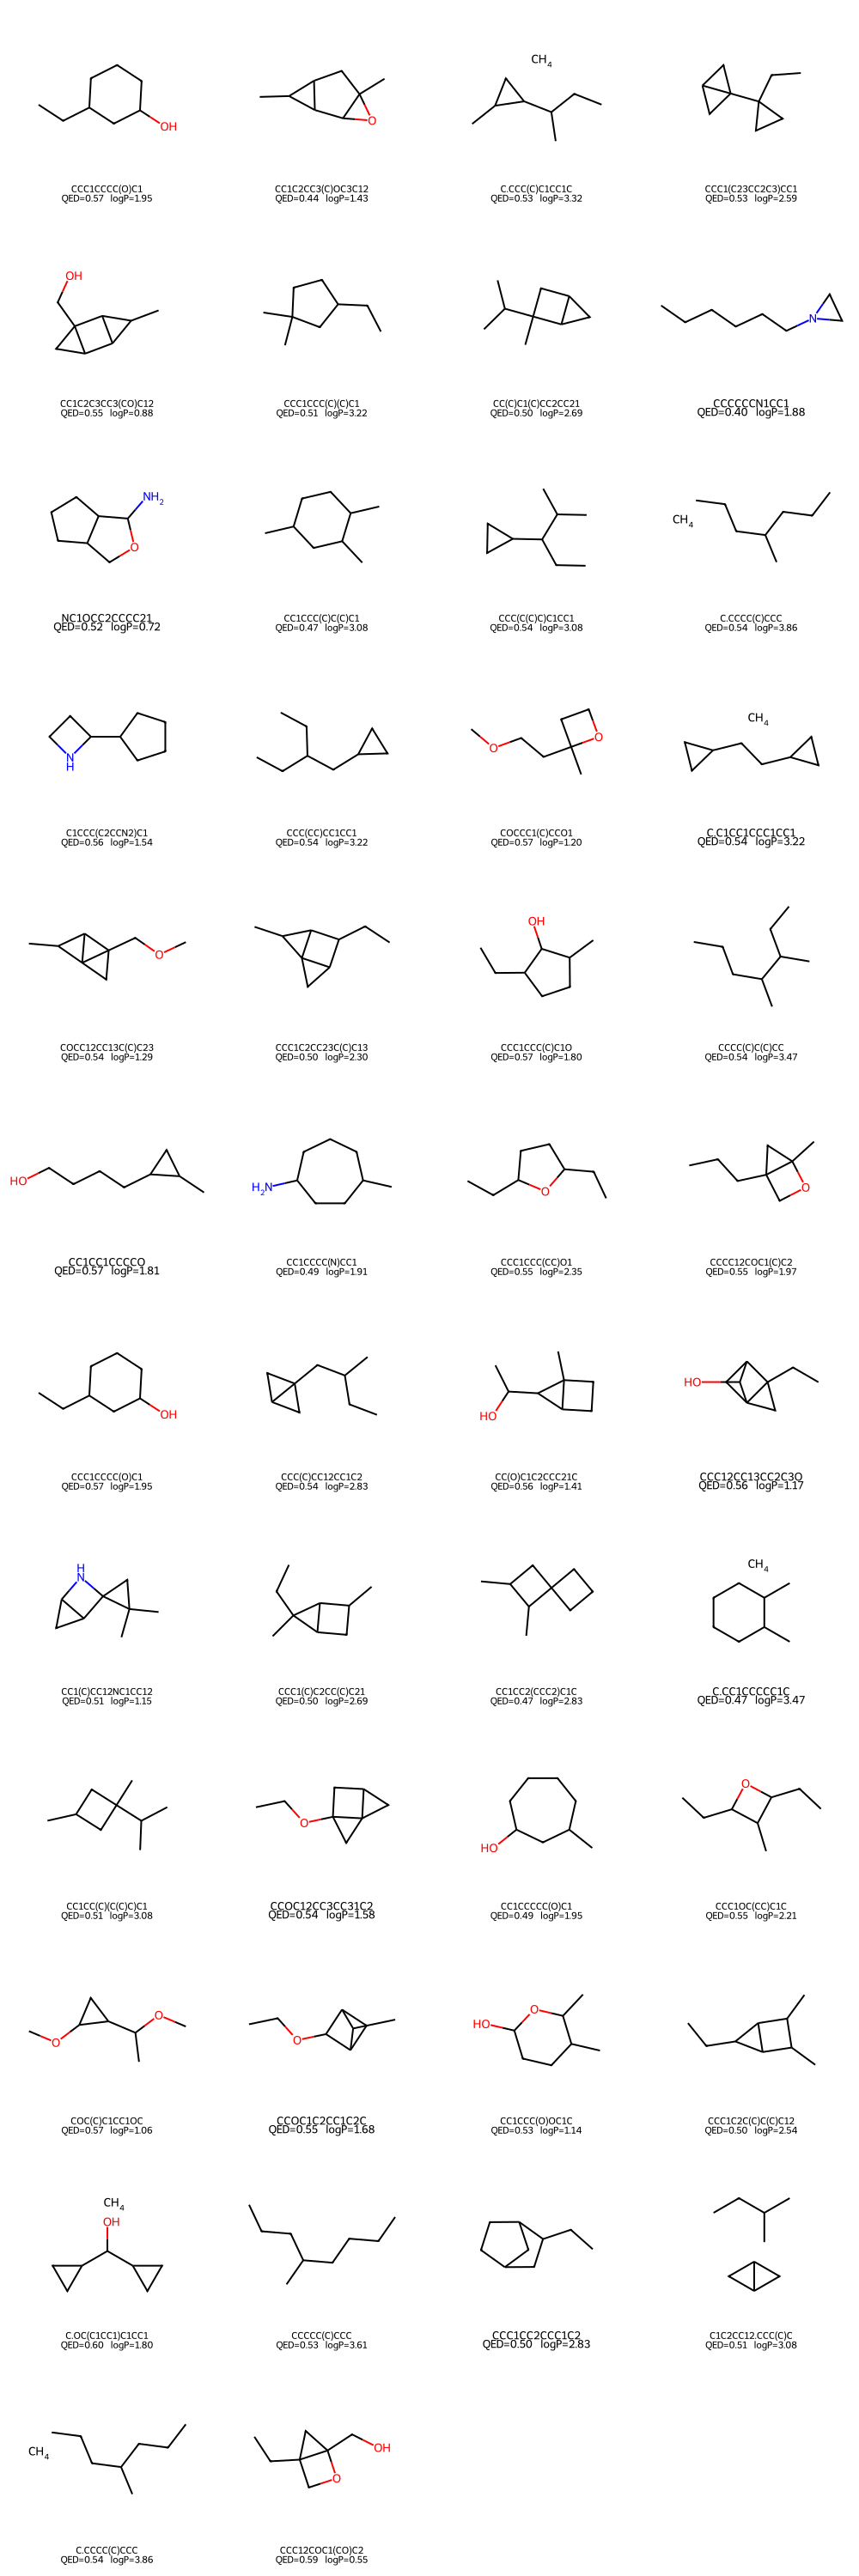

In [110]:
def visualise_2d(mols: list,
                 smiles: list,
                 max_display: int = None):
    """Display all valid molecules in a grid using RDKit with SMILES."""

    if not mols:
        print("No valid molecules to display.")
        return

    valid_count = len(mols)

    print(f"Total valid molecules generated: {valid_count}")

    if max_display is None:
        max_display = valid_count

    display_mols = mols[:max_display]
    display_smiles = smiles[:max_display]

    legends = [
        f"{s}\nQED={calculate_qed(m):.2f}  logP={calculate_logp(m):.2f}"
        for m, s in zip(display_mols, display_smiles)
    ]

    grid_img = Draw.MolsToGridImage(
        display_mols,
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends,
    )

    display(grid_img)

    return grid_img
print("2D grid visualisation:")
grid = visualise_2d(generated_mols, generated_smiles)

## Section 21 — 3D Molecule Visualisation

In [111]:
def visualise_3d(mol, width: int = 600, height: int = 400):
    """
    Generate 3D coordinates with RDKit + render interactively with py3Dmol.
    Supports rotation, zoom, and bond visualisation.
    """
    if mol is None:
        print("No molecule provided.")
        return

    if not PY3DMOL_AVAILABLE:
        print("py3Dmol not installed — skipping 3D visualisation.")
        return

    # Add hydrogens and embed 3D
    mol_h = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())
    if result != 0:
        # Fallback to basic ETDG
        result = AllChem.EmbedMolecule(mol_h)
    if result != 0:
        print("3D embedding failed — try another molecule.")
        return

    AllChem.UFFOptimizeMolecule(mol_h)

    mol_block = Chem.MolToMolBlock(mol_h)

    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModel(mol_block, 'mol')
    viewer.setStyle({'stick': {}, 'sphere': {'radius': 0.3}})
    viewer.setBackgroundColor('0x1a1a2e')
    viewer.zoomTo()
    viewer.show()


if generated_mols:
    print(f"3D view of first generated molecule: {generated_smiles[0]}")
    visualise_3d(generated_mols[0])
else:
    print("No molecules available for 3D visualisation.")


3D view of first generated molecule: CCC1CCCC(O)C1
py3Dmol not installed — skipping 3D visualisation.


## Section 22 — Validity / Novelty / Uniqueness

In [112]:
def compute_metrics(generated_smiles: list,
                    training_smiles: list,
                    total_requested: int) -> dict:
    """
    Compute molecular generation metrics.

    Validity   = valid / total_requested
    Novelty    = new molecules / valid
    Uniqueness = unique molecules / valid
    """

    n_valid = len(generated_smiles)

    if total_requested == 0:
        return {
            'validity': 0.0,
            'novelty': 0.0,
            'uniqueness': 0.0,
            'n_valid': 0,
            'n_total': 0,
        }

    validity = n_valid / total_requested

    uniqueness = (
        len(set(generated_smiles)) / n_valid
        if n_valid else 0.0
    )

    training_set = set(training_smiles)

    novel = [
        s for s in generated_smiles
        if s not in training_set
    ]

    novelty = (
        len(novel) / n_valid
        if n_valid else 0.0
    )

    return {
        'validity': validity,
        'novelty': novelty,
        'uniqueness': uniqueness,
        'n_valid': n_valid,
        'n_total': total_requested,
    }
# Collect training SMILES for novelty check
training_smiles = df['smiles'].tolist()

metrics = compute_metrics(generated_smiles, training_smiles,NUMBER_OF_MOLECULES)
print("\n── Molecular Generation Metrics ──────────────────────────")
print(f"  Validity   : {metrics['validity']  *100:.1f}%  "
      f"({metrics['n_valid']}/{metrics['n_total']})")
print(f"  Uniqueness : {metrics['uniqueness']*100:.1f}%")
print(f"  Novelty    : {metrics['novelty']   *100:.1f}%")
print("────────────────────────────────────────────────────────")


── Molecular Generation Metrics ──────────────────────────
  Validity   : 92.0%  (46/50)
  Uniqueness : 95.7%
  Novelty    : 100.0%
────────────────────────────────────────────────────────


## Section 23 — Property Reporting

In [113]:

def report_properties(mols: list, smiles_list: list):
    """Print a formatted table of molecular properties."""
    rows = []
    for smi, mol in zip(smiles_list, mols):
        rows.append({
            'SMILES'            : smi,
            'QED'               : round(calculate_qed(mol), 4),
            'logP'              : round(calculate_logp(mol), 4),
            'SA Score'          : round(calculate_sa_score(mol), 4),
            'Mol Weight (Da)'   : round(calculate_molecular_weight(mol), 3),
        })
    report_df = pd.DataFrame(rows)
    print(report_df.to_string(index=False))
    return report_df


print("\n── Generated Molecule Properties ─────────────────────────")
prop_report = report_properties(generated_mols, generated_smiles)



── Generated Molecule Properties ─────────────────────────
           SMILES    QED   logP  SA Score  Mol Weight (Da)
    CCC1CCCC(O)C1 0.5719 1.9475    2.8160          128.120
CC1C2CC3(C)OC3C12 0.4449 1.4297    4.9305          124.089
   C.CCC(C)C1CC1C 0.5349 3.3246    3.6109          128.157
CCC1(C23CC2C3)CC1 0.5278 2.5866    3.4004          122.110
CC1C2C3CC3(CO)C12 0.5499 0.8807    4.9989          124.089
  CCC1CCC(C)(C)C1 0.5058 3.2227    2.8203          126.141
CC(C)C1(C)CC2CC21 0.5039 2.6885    4.3444          124.125
      CCCCCCN1CC1 0.4023 1.8823    1.4624          127.136
    NC1OCC2CCCC21 0.5200 0.7177    4.1227          127.100
  CC1CCC(C)C(C)C1 0.4677 3.0786    3.0374          126.141
  CCC(C(C)C)C1CC1 0.5449 3.0786    3.1219          126.141
     C.CCCC(C)CCC 0.5418 3.8588    2.1848          130.172
  C1CCC(C2CCN2)C1 0.5602 1.5385    2.7615          125.120
    CCC(CC)CC1CC1 0.5422 3.2227    2.2650          126.141
    COCCC1(C)CCO1 0.5712 1.2019    3.2108          130.

In [ ]:
# ── Step 1: Compute Score ─────────────────────────────────────────────────────
results_df["score"] = abs(results_df["qed"] - TARGET_QED) + abs(results_df["logp"] - TARGET_LOGP)

# ── Step 2: Sort DataFrame ────────────────────────────────────────────────────
results_df = results_df.sort_values(
    by="score",
    ascending=True
).reset_index(drop=True)

# ── Step 3: Select ONE Suggested Molecule ─────────────────────────────────────
if not results_df.empty:
    best_molecule = results_df.iloc[0]

    print("Suggested Molecule (Closest to Target Properties)\n")
    print(f"SMILES: {best_molecule['smiles']}")
    print(f"QED:    {best_molecule['qed']:.4f}")
    print(f"logP:   {best_molecule['logp']:.4f}")
    print(f"SA:     {best_molecule['sa']:.4f}")
    print(f"MW:     {best_molecule['mw']:.3f}")
    print(f"Score:  {best_molecule['score']:.4f}\n")

    # Render the single best molecule
    best_mol = Chem.MolFromSmiles(best_molecule["smiles"])
    if best_mol is not None:
        best_img = Draw.MolToImage(best_mol)
        display(best_img)
    else:
        print("  [Warning] Could not parse SMILES for image rendering.")
else:
    print("No molecules available — skipping suggestion.")

# ── Step 4: Display all molecules in sorted order ─────────────────────────────
print("\n── Sorted molecule grid (closest to target properties first) ──")

sorted_mols    = []

for _, row in results_df.iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:          # skip invalid SMILES safely
        continue
    sorted_mols.append(mol)

if sorted_mols:
    grid_img_sorted = Draw.MolsToGridImage(
        sorted_mols,
        molsPerRow=5,
        subImgSize=(300, 300)
    )
    display(grid_img_sorted)
else:
    print("No valid molecules to display.")

## Section 24 — Final Execution Summary

In [114]:
print("=" * 60)
print("           molgan_updates — Run Summary")
print("=" * 60)
print(f"  Dataset molecules used : {len(mol_dataset)}")
print(f"  Training epochs        : {NUM_EPOCHS}")
print(f"  Target QED             : {TARGET_QED}")
print(f"  Target logP            : {TARGET_LOGP}")
print(f"  Noise temperature      : {TEMPERATURE}")
print(f"  Replay buffer size     : {len(replay_buffer)}")
print()
print(f"  ── Metrics ──────────────────────────────────────")
print(f"  Validity   : {metrics['validity']  *100:.1f}%")
print(f"  Uniqueness : {metrics['uniqueness']*100:.1f}%")
print(f"  Novelty    : {metrics['novelty']   *100:.1f}%")
print()
print("  ── Visualisations ───────────────────────────────")
print("  2D grid  : displayed above (up to 16 molecules)")
print("  3D viewer: interactive py3Dmol widget")
print()
print("  ── Checkpoints ──────────────────────────────────")
ckpts = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("ckpt_")])
for c in ckpts:
    print(f"  {c}")
print("=" * 60)
print("Done.")


           molgan_updates — Run Summary
  Dataset molecules used : 130675
  Training epochs        : 50
  Target QED             : 0.5
  Target logP            : 2.8
  Noise temperature      : 0.8
  Replay buffer size     : 0

  ── Metrics ──────────────────────────────────────
  Validity   : 92.0%
  Uniqueness : 95.7%
  Novelty    : 100.0%

  ── Visualisations ───────────────────────────────
  2D grid  : displayed above (up to 16 molecules)
  3D viewer: interactive py3Dmol widget

  ── Checkpoints ──────────────────────────────────
Done.


In [115]:
torch.save(generator.state_dict(), "molgan_gen.pth")

In [105]:
try:
    from google.colab import files
    files.download('molgan_gen.pth')
    print('[OK] Download started.')
except ImportError:
    print('Not running in Colab -- copy the file manually.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] Download started.
